## Model Training


### 1.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn, and Warnings Library.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings

warnings.simplefilter("ignore")

#### Import the CSV data into Dataframe


In [3]:
df = pd.read_csv("data/stud.csv")

#### Show Top 5 Data


In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables


In [5]:
X = df.drop(columns=["math_score"], axis=1)
y = df["math_score"]

In [6]:
cat_features = [feature for feature in X.columns if X[feature].dtype == "O"]
num_features = [feature for feature in X.columns if X[feature].dtype != "O"]
discrete_features = [feature for feature in num_features if X[feature].nunique() <= 20]
continuous_features = [
    feature for feature in num_features if feature not in discrete_features
]


print("Total Categorical Features:", len(cat_features))
print("Total Numerical Features:", len(num_features))
print("Total Discrete Features:", len(discrete_features))
print("Total Continuous Features:", len(continuous_features))

Total Categorical Features: 5
Total Numerical Features: 2
Total Discrete Features: 0
Total Continuous Features: 2


In [7]:
for feature in cat_features:
    print(f"Total unique values of '{feature}': {df[feature].nunique()}")

Total unique values of 'gender': 2
Total unique values of 'race_ethnicity': 5
Total unique values of 'parental_level_of_education': 6
Total unique values of 'lunch': 2
Total unique values of 'test_preparation_course': 2


In [8]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

onehot_pipeline = Pipeline(steps=[("onehot", OneHotEncoder(drop="first"))])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", onehot_pipeline, cat_features),
        ("StandardScaler", StandardScaler(), num_features),
    ]
)

In [9]:
X = preprocessor.fit_transform(X)

In [10]:
X.shape

(1000, 14)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((800, 14), (200, 14))

#### Create an Evaluate Function to give all metrics after model Training


In [12]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
}

model_list = []
mae_list = []
rmse_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    # Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test Dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for Training set")
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)
    mae_list.append(model_test_mae)
    rmse_list.append(model_test_rmse)

    print("=" * 35)
    print("\n")

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3235
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3936
- Mean Absolute Error: 4.2125
- R2 Score: 0.8805


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.5678
- Mean Absolute Error: 4.4510
- R2 Score: 0.8625
-----------------------

In [32]:
pd.DataFrame(
    zip(model_list, r2_list, mae_list, rmse_list),
    columns=["Model Name", "R2_Score", "MAE", "RMSE"],
).sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score,MAE,RMSE
2,Ridge,0.880451,4.212515,5.393586
0,Linear Regression,0.880433,4.214763,5.393994
5,Random Forest Regressor,0.855254,4.603346,5.934833
7,CatBoosting Regressor,0.849801,4.633506,6.045589
8,AdaBoost Regressor,0.842821,4.873875,6.184467
1,Lasso,0.825320,5.157882,6.519695
6,XGBRegressor,0.825046,5.078543,6.524809
3,K-Neighbors Regressor,0.776335,5.711000,7.377411
4,Decision Tree,0.720430,6.500000,8.248030


## Ridge Regression


In [38]:
model = Ridge(fit_intercept=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred) * 100
print(f"The Accuracy Model of Ridge is {score}")

The Accuracy Model of Ridge is 88.04513937125637


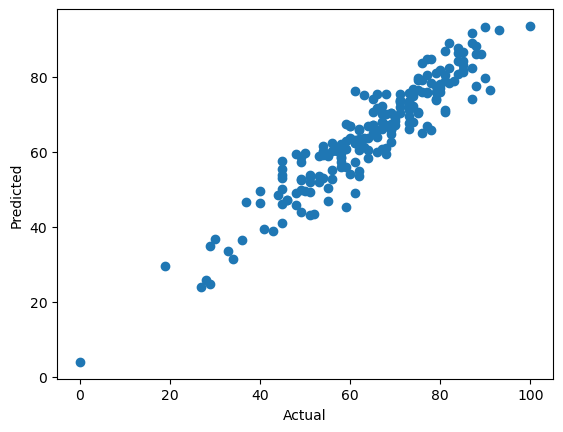

In [51]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [52]:
model.coef_

array([12.95326583,  0.29421045, -0.68057152, -0.63981574,  4.79067764,
       -0.69276916,  0.89742164, -1.3655851 ,  0.98798206,  0.71490942,
        3.52714381,  3.21709075,  3.61277594, 10.78929324])

In [53]:
model.intercept_

54.84695384873156

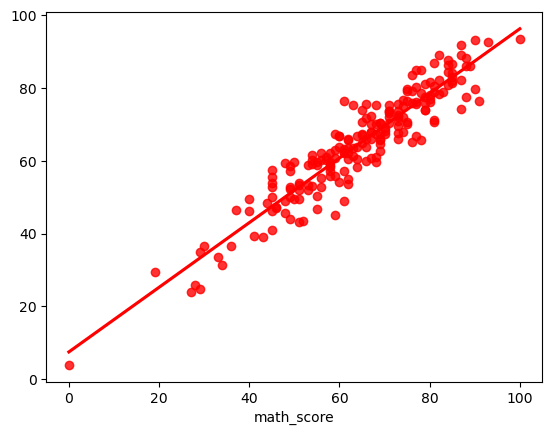

In [56]:
sns.regplot(x=y_test, y=y_pred, ci=None, color="red")

In [60]:
data = {
    "Actual Value": y_test,
    "Predicted Value": y_pred,
    "Difference": y_test - y_pred,
}

pred_df = pd.DataFrame(data)
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.405205,14.594795
737,53,58.858134,-5.858134
740,80,76.963473,3.036527
660,74,76.776989,-2.776989
411,84,87.595617,-3.595617
...,...,...,...
408,52,43.528947,8.471053
332,62,62.163717,-0.163717
208,74,67.919929,6.080071
613,65,67.073265,-2.073265
